# Teaching Assistant 


## Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a model to classify the data points into given labels. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

## Load Dataset

In [4]:
df = pd.read_csv("tae.csv", header=None)
df.head()

,0,1,2,3,4,5
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       151 non-null    int64
 1   1       151 non-null    int64
 2   2       151 non-null    int64
 3   3       151 non-null    int64
 4   4       151 non-null    int64
 5   5       151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [4]:
df.describe()

,1,23,3,1.1,19,3.1
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.813333,13.580000,8.140000,1.853333,27.926667,2.013333
std,0.390949,6.805318,7.034937,0.354958,12.916405,0.819123
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.500000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


## Rename Columns  (avoid errors)

In [6]:
df.columns = ['English speaker', 'Course instructor', 'Course', 
              'Summer or Regular', 'Class size', 'Class']
df.head()

,English speaker,Course instructor,Course,Summer or Regular,Class size,Class
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


## Check Missing Values

In [6]:
df.isnull().sum()

English_speaker      0
Course_instructor    0
Course               0
Summer_or_Regular    0
Class_size           0
Class_attribute      0
dtype: int64

## Encode Categorical Variables  (converting text data into numerical values)

In [7]:
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
df.head()

,English speaker,Course instructor,Course,Summer or Regular,Class size,Class
0,0,22,2,0,13,2
1,1,14,2,0,11,2
2,0,22,2,1,40,2
3,0,4,1,1,27,2
4,1,6,10,1,43,2


## Feature and Target Split (Train = Learn ,Test = Check performance on unseen data)

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  #42 is just a common number (you can use any number).

## Logistic Regression Model

In [9]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.5333333333333333
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        14
           1       0.45      0.45      0.45        11
           2       0.25      0.20      0.22         5

    accuracy                           0.53        30
   macro avg       0.46      0.46      0.46        30
weighted avg       0.52      0.53      0.53        30



## Random Forest Model

In [11]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7096774193548387
              precision    recall  f1-score   support

           0       0.71      0.91      0.80        11
           1       0.78      0.64      0.70        11
           2       0.62      0.56      0.59         9

    accuracy                           0.71        31
   macro avg       0.71      0.70      0.70        31
weighted avg       0.71      0.71      0.70        31



## Feature Importance  (useful for making predictions)

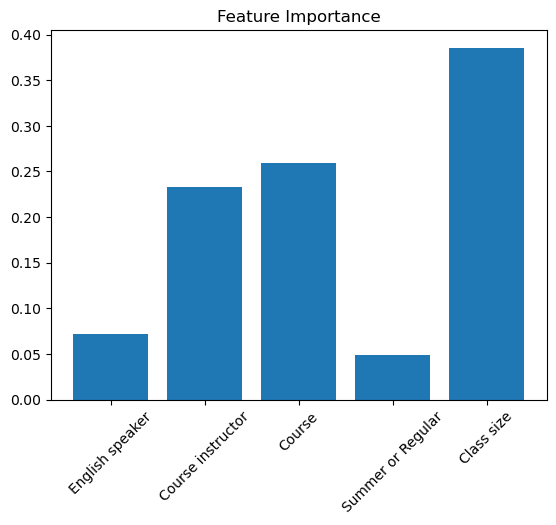

In [17]:
importances = rf_model.feature_importances_
plt.figure()
plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.show()

## Conclusion
In this project, we performed classification using Logistic Regression and Random Forest.
Random Forest generally performs better for this dataset.


# Report on Challenges faced
1️. Incorrect Column Headers
    ['1', '23', '3', '1.1', '19', '3.1']

  Reason:
  Proper column names are necessary for:
  Easy coding
  Avoiding errors

2.Some features like semester, course instructor, etc., were categorical (text values).
  Machine learning models cannot work directly with text data.
  Reason:Label Encoding converts text categories into numeric format, which ML algorithms require.


3.Data Splitting


4.Techniques Used
  Logistic Regression: Works well for small datasets
  Random Forest :Handles categorical data well
  Confusion Matrix: Understand type of errors
  Feature Importance.
